"生成不同模型拿到相同 addend pairs 后生成的 sum 图片的示例图。\n",
"输入：exp_group（假设是n组对比试验），dataset_config，find_addend_pairs（假设是m个加法pairs）。\n",
"输出：一个除了首行外全是图片的表格，展示不同模型对于不同加法pair的预测生成。第一列\"Addend 1\"的图片, 第二列\"Addend 2\"的图片, 第三列\"Sum\"的图片。这三个都可以在一个 data sample里找到，对应 a,b,c。第4到n+4列是 n 个模型预测的 sum 图片。\n",
"第一行，标题。\"Addend 1\", \"Addend 2\", \"Sum\", 以及 n 个模型的 alias。\n",
"第2到m+2行则是 m 个加法 pair 的结果展示。\n",

"你应先加载dataloader（shuffle=true），然后从dataloader中根据find_addend_pairs找到m个加法pair，及时dataset中有多于m个满足条件的pairs也只找m个，保存 m 个 a,b,c 数字的图片。然后分别加载exp_group的每个实验，获得它们预测 a+b 的输出 c'。最后运行画图代码。\n",

"如何加载数据集，加载实验，运行模型等可以参考 VQ\\eval_pipeline.py 和 VQ\\train.py 以及它们 import 的代码。\n"


In [4]:
import os
import sys
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import ConcatDataset, DataLoader

if '__file__' in globals():
    notebook_dir = Path(__file__).resolve().parent
else:
    cwd = Path.cwd().resolve()
    notebook_dir = cwd / 'VQ' / 'plots' if (cwd / 'VQ' / 'plots').exists() else cwd

project_root = notebook_dir.parents[1]
vq_root = project_root / 'VQ'
for path in (project_root, vq_root):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from VQVAE import VQVAE
from common_func import (
    EXP_ROOT,
    find_optimal_checkpoint_num_by_train_config,
    load_config_from_exp_name,
    make_dataset_trans,
    parse_label,
)
from dataloader_plus import MultiImgDataset
from shared import DEVICE

data_root = project_root / 'dataset'


def make_plus_data_loader(dataset_cfg: Dict[str, Any], shuffle: bool = True) -> DataLoader:
    transform = make_dataset_trans(dataset_cfg.get('is_blur', False), dataset_cfg.get('blur_cfg', {}))
    datasets = [
        MultiImgDataset(str(path), augment_times=dataset_cfg.get('augment_times', 1), transform=transform)
        for path in dataset_cfg['path_list']
    ]
    dataset = ConcatDataset(datasets)
    return DataLoader(dataset, batch_size=128, shuffle=shuffle)


def resolve_checkpoint_path(exp_item: Dict[str, str]) -> Tuple[Dict[str, Any], str]:
    config = load_config_from_exp_name(exp_item['exp_name'])
    exp_path = os.path.join(EXP_ROOT, exp_item['exp_name'])
    ckpt_name = exp_item.get('ckpt')
    if ckpt_name:
        ckpt_path = os.path.join(exp_path, exp_item['sub_exp'], ckpt_name)
    else:
        ckpt_num = find_optimal_checkpoint_num_by_train_config(
            os.path.join(exp_path, exp_item['sub_exp']),
            config,
            config['eval_config'].get('optimal_checkpoint_finding_config'),
        )
        ckpt_path = os.path.join(exp_path, exp_item['sub_exp'], f'checkpoint_{ckpt_num}.pt')
    return config, ckpt_path


def tensor_to_image(tensor: torch.Tensor) -> np.ndarray:
    return tensor.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()


def find_requested_samples(data_loader: DataLoader, target_pairs: List[Tuple[int, int]]) -> List[Dict[str, Any]]:
    found = {}
    target_set = set(target_pairs)

    for batch_data, batch_labels in data_loader:
        batch_size = batch_data[0].size(0)
        for idx in range(batch_size):
            a_label = parse_label(batch_labels[0][idx])
            b_label = parse_label(batch_labels[1][idx])
            c_label = parse_label(batch_labels[2][idx])
            pair = (a_label, b_label)
            if pair not in target_set or pair in found:
                continue
            found[pair] = {
                'pair': pair,
                'labels': (a_label, b_label, c_label),
                'a_img': batch_data[0][idx].detach().cpu(),
                'b_img': batch_data[1][idx].detach().cpu(),
                'c_img': batch_data[2][idx].detach().cpu(),
                'a_name': batch_labels[0][idx],
                'b_name': batch_labels[1][idx],
                'c_name': batch_labels[2][idx],
            }
            if len(found) == len(target_pairs):
                return [found[pair] for pair in target_pairs]

    missing = [pair for pair in target_pairs if pair not in found]
    print(f'Error: missing addend pairs in dataset: {missing}')
    raise ValueError(f'Could not find all requested addend pairs. Missing: {missing}')


def generate_predictions(sample_rows: List[Dict[str, Any]], exp_items: List[Dict[str, str]]) -> Dict[str, List[torch.Tensor]]:
    batch_a = torch.stack([row['a_img'] for row in sample_rows], dim=0).to(DEVICE)
    batch_b = torch.stack([row['b_img'] for row in sample_rows], dim=0).to(DEVICE)
    batch_c = torch.stack([row['c_img'] for row in sample_rows], dim=0).to(DEVICE)
    outputs = {}

    with torch.no_grad():
        for exp_item in exp_items:
            config, ckpt_path = resolve_checkpoint_path(exp_item)
            model = VQVAE(config).to(DEVICE)
            model.load_state_dict(model.load_tensor(ckpt_path))
            model.eval()

            zc_dim = config['latent_embedding_1'] * config['embedding_dim']
            za = model.batch_encode_to_z(batch_a)[0]
            zb = model.batch_encode_to_z(batch_b)[0]
            zc = model.batch_encode_to_z(batch_c)[0]

            style = zc[..., zc_dim:]
            if config['isVQStyle']:
                style = model.vq_layer(style)[0]

            plus_content = model.plus(za[..., :zc_dim], zb[..., :zc_dim])[0]
            pred_c = model.batch_decode_from_z(torch.cat((plus_content, style), dim=-1))
            outputs[exp_item['alias']] = [img.detach().cpu() for img in pred_c]

    return outputs


def plot_sample_table(sample_rows: List[Dict[str, Any]], predictions: Dict[str, List[torch.Tensor]], save_path: Path):
    headers = ['Addend 1', 'Addend 2', 'Sum'] + list(predictions.keys())
    row_num = len(sample_rows) + 1
    col_num = len(headers)
    fig, axes = plt.subplots(
        row_num,
        col_num,
        figsize=(2.2 * col_num, 2.2 * row_num),
        squeeze=False,
        gridspec_kw={'wspace': 0.08, 'hspace': 0.08},
    )

    for col_idx, header in enumerate(headers):
        axes[0][col_idx].text(0.5, 0.5, header, ha='center', va='center', fontsize=14, fontweight='bold')
        axes[0][col_idx].axis('off')

    for row_idx, row in enumerate(sample_rows, start=1):
        row_images = [row['a_img'], row['b_img'], row['c_img']] + [predictions[alias][row_idx - 1] for alias in predictions]
        for col_idx, image in enumerate(row_images):
            axes[row_idx][col_idx].imshow(tensor_to_image(image))
            axes[row_idx][col_idx].axis('off')

    fig.canvas.draw()
    divider_x = (axes[0][2].get_position().x1 + axes[0][3].get_position().x0) / 2
    divider = plt.Line2D(
        [divider_x, divider_x],
        [axes[-1][0].get_position().y0, axes[0][0].get_position().y1],
        transform=fig.transFigure,
        color='#d9d9d9',
        linewidth=0.8,
    )
    fig.add_artist(divider)

    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    return fig


Loading config from: D:\Projects\Gus Xia\S3Plus\VQ\exp\2025.05.15_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_Fullsymm\train_config.py
Loading config from: D:\Projects\Gus Xia\S3Plus\VQ\exp\2025.05.15_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_Nothing\train_config.py
Loading config from: D:\Projects\Gus Xia\S3Plus\VQ\exp\2025.06.10_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_PureVQ\train_config.py
Loading config from: D:\Projects\Gus Xia\S3Plus\VQ\exp\2025.05.19_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_Nothing_trainAll\train_config.py


C:\Users\Lxj\AppData\Local\Temp\ipykernel_73580\2724926487.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


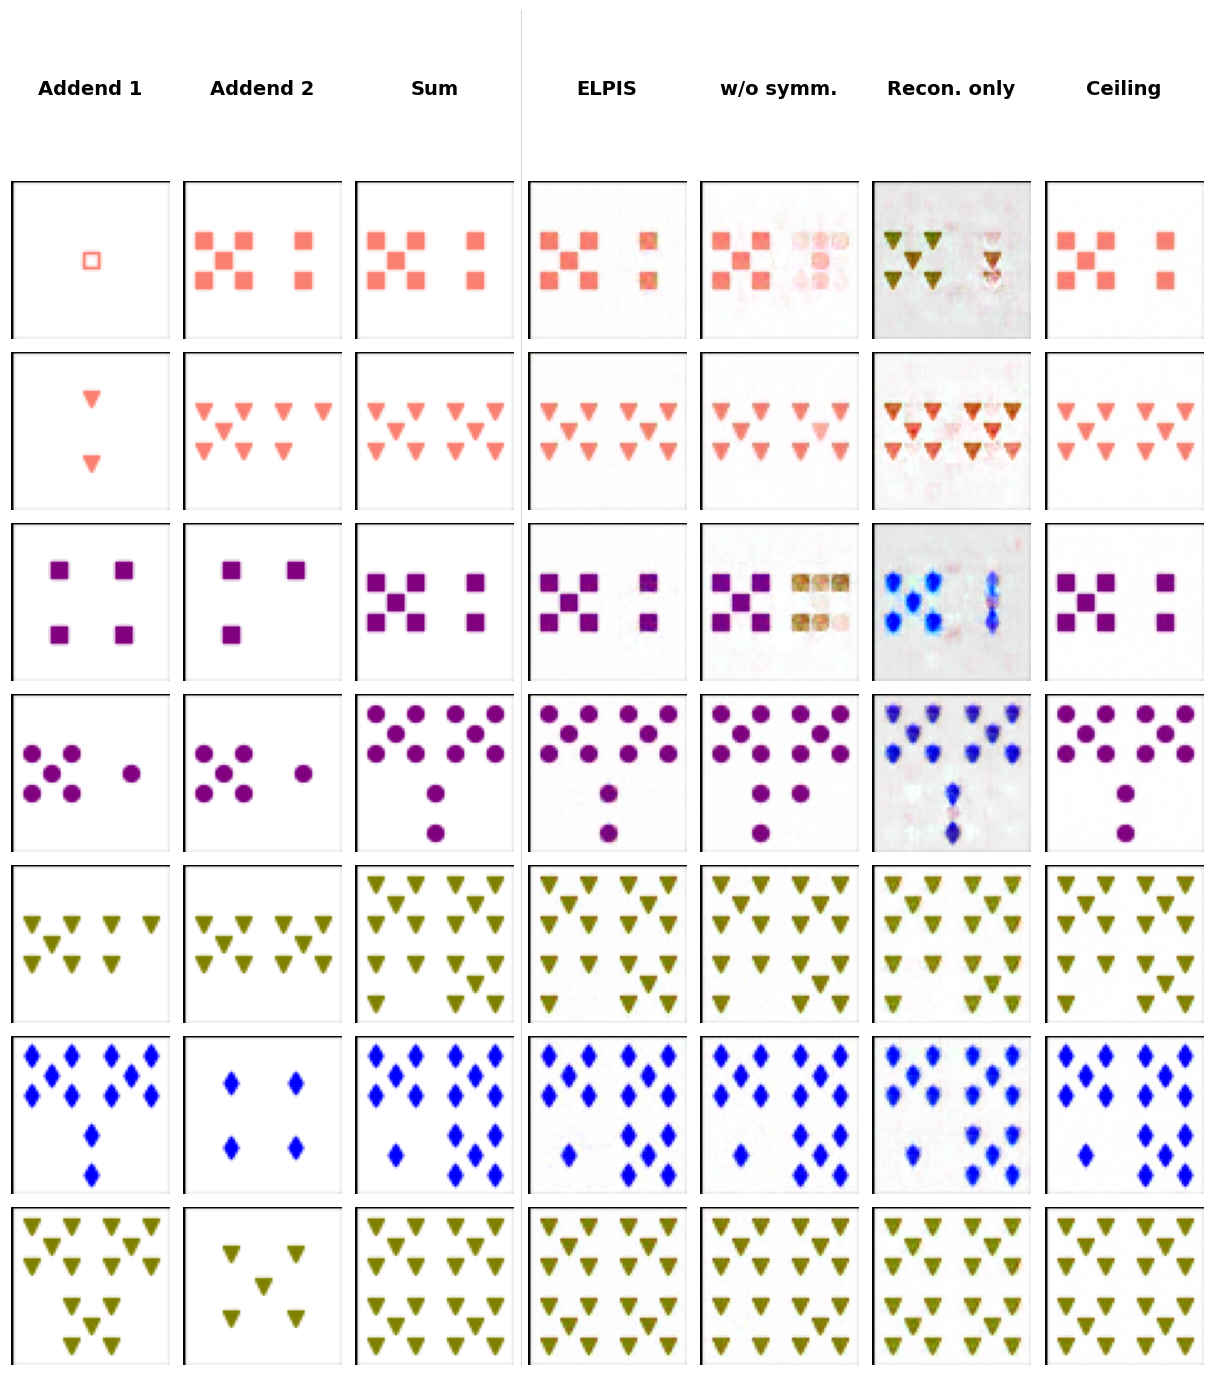

Saved figure to: D:\Projects\Gus Xia\S3Plus\VQ\plots\generate_samples\multiStyle.svg


[{'pair': (0, 7),
  'labels': (0, 7, 7),
  'a_img': tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.8902, 0.9451,  ..., 0.9451, 0.9451, 0.8902],
           [0.0000, 0.9451, 1.0000,  ..., 1.0000, 1.0000, 0.9451],
           ...,
           [0.0000, 0.9451, 1.0000,  ..., 1.0000, 1.0000, 0.9451],
           [0.0000, 0.9451, 1.0000,  ..., 1.0000, 1.0000, 0.9451],
           [0.0000, 0.8902, 0.9451,  ..., 0.9451, 0.9451, 0.8902]],
  
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.8902, 0.9451,  ..., 0.9451, 0.9451, 0.8902],
           [0.0000, 0.9451, 1.0000,  ..., 1.0000, 1.0000, 0.9451],
           ...,
           [0.0000, 0.9451, 1.0000,  ..., 1.0000, 1.0000, 0.9451],
           [0.0000, 0.9451, 1.0000,  ..., 1.0000, 1.0000, 0.9451],
           [0.0000, 0.8902, 0.9451,  ..., 0.9451, 0.9451, 0.8902]],
  
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.8902, 0.9451,  ..

In [5]:
figure_name = "multiStyle.svg"
save_dir = "generate_samples/"

exp_group = [
    {
        'exp_name': "2025.05.15_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_Fullsymm",
        'sub_exp': "1",
        'ckpt': "curr_model.pt",
        'alias': "ELPIS",
    },
    {
        'exp_name': "2025.05.15_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_Nothing",
        'sub_exp': "1",
        'ckpt': "curr_model.pt",
        'alias': "w/o symm.",
    },
    {
        'exp_name': "2025.06.10_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_PureVQ",
        'sub_exp': "1",
        'ckpt': "curr_model.pt",
        'alias': "Recon. only",
    },
    {
        'exp_name': "2025.05.19_10vq_Zc[2]_Zs[0]_edim1_[0-20]_plus1024_1_multiStyle_Nothing_trainAll",
        'sub_exp': "1",
        'ckpt': "curr_model.pt",
        'alias': "Ceiling",
    },
]

dataset_config = {
    'path_list': [str(data_root / 'multi_style_(4,4)_realPairs_plus(0,20)' / 'test')],
    'is_blur': False,
    'augment_times': 1,
    'blur_cfg': {
        'kernel_size_choices': (5, 7, 9),
        'sigma_range': (0.5, 3.0),
        'p_no_blur': 0.00,
    },
}

find_addend_pairs = [
    (0, 7),
    (2, 8),
    (4, 3),
    (6, 6),
    (8, 10),
    (12, 4),
    (15, 5),
]

data_loader = make_plus_data_loader(dataset_config, shuffle=True)
sample_rows = find_requested_samples(data_loader, find_addend_pairs)
predictions = generate_predictions(sample_rows, exp_group)

output_path = notebook_dir / save_dir / figure_name
plot_sample_table(sample_rows, predictions, output_path)
print(f"Saved figure to: {output_path}")
sample_rows
